## Predicción de tráfico

### Carga de datos

In [237]:
import pandas as pd

'''
Leer datos del dataset 'traffic.csv'
'''

dataFrame = pd.read_csv('traffic.csv')

'''
Comprobar si hay duplicados en el dataset
    - Si lo hay los elimina en el propio dataset en vez de crear otro nuevo
'''

num_duplicados = dataFrame.duplicated().sum()

if num_duplicados > 0:
    dataFrame.drop_duplicates(inplace = True)
    print('Duplicados eleiminados correctamente')
    print(f'Nuevo tamaño del dataset: {dataFrame.shape}')
else: print('No se encontraron duplicados. Dataset limpio')

'''
Mostrar las columnas del dataset
'''

dataFrame

No se encontraron duplicados. Dataset limpio


,DateTime,Junction,Vehicles,ID
0,2015-11-01 00:00:00,1,15,20151101001
1,2015-11-01 01:00:00,1,13,20151101011
2,2015-11-01 02:00:00,1,10,20151101021
3,2015-11-01 03:00:00,1,7,20151101031
4,2015-11-01 04:00:00,1,9,20151101041
...,...,...,...,...
48115,2017-06-30 19:00:00,4,11,20170630194
48116,2017-06-30 20:00:00,4,30,20170630204
48117,2017-06-30 21:00:00,4,16,20170630214
48118,2017-06-30 22:00:00,4,22,20170630224


### Preprocesado

##### DataFrame

In [238]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

'''
Creamos otro dataset con nuevas columnas
'''

dataFrame['DateTime'] = pd.to_datetime(dataFrame['DateTime'])

nuevoDataFrame = dataFrame.copy()

nuevoDataFrame['Hour'] = dataFrame['DateTime'].dt.hour
nuevoDataFrame['DayOfWeek'] = dataFrame['DateTime'].dt.dayofweek
nuevoDataFrame['Month'] = dataFrame['DateTime'].dt.month
nuevoDataFrame['DayOfMonth'] = dataFrame['DateTime'].dt.day
nuevoDataFrame['WeekOfYear'] = dataFrame['DateTime'].dt.isocalendar().week.astype(int)
nuevoDataFrame['IsWeekend'] = (nuevoDataFrame['DayOfWeek'] >= 5).astype(int)
nuevoDataFrame['HourSin'] = np.sin(2 * np.pi * nuevoDataFrame['Hour'] / 24)
nuevoDataFrame['HourCos'] = np.cos(2 * np.pi * nuevoDataFrame['Hour'] / 24)
nuevoDataFrame['DoWSin'] = np.sin(2 * np.pi * nuevoDataFrame['DayOfWeek'] / 7)
nuevoDataFrame['DoWCos'] = np.cos(2 * np.pi * nuevoDataFrame['DayOfWeek'] / 7)

for lag in [1, 2, 3, 6, 12, 24, 48]: nuevoDataFrame[f'Lag_{lag}'] = dataFrame['Vehicles'].shift(lag)

for w in [3, 6, 12, 24]:
    nuevoDataFrame[f'Roll_mean_{w}'] = dataFrame['Vehicles'].shift(1).rolling(w).mean()
    nuevoDataFrame[f'Roll_std_{w}'] = dataFrame['Vehicles'].shift(1).rolling(w).std()

'''
Eliminamos las columnas donde faltan valores y la columnda de IDs, y ordenamos por fecha
'''

nuevoDataFrame = nuevoDataFrame.dropna().reset_index(drop = True)
nuevoDataFrame.drop(['ID'], axis = 1, inplace = True)
nuevoDataFrame = nuevoDataFrame.sort_values('DateTime').reset_index(drop = True)

'''
Aplicamos One-Hot Encoding a la columna 'Junction'
    - Se elimina un valor porque la codificacion 000...000 hace referencia al valor restante que se elimina
'''

oneHotEncoder = OneHotEncoder(drop = 'first')
oneHotEncoderFit = oneHotEncoder.fit(nuevoDataFrame['Junction'].values.reshape(-1, 1))
junctionEncoded = oneHotEncoderFit.transform(nuevoDataFrame['Junction'].values.reshape(-1, 1)).toarray()

ini = nuevoDataFrame['Junction'].min()
fin = nuevoDataFrame['Junction'].max()

nuevasJunctions = []
for idx in range(ini + 1, fin + 1): nuevasJunctions.append(F'Junction_{idx}')

nuevoDataFrame[nuevasJunctions] = junctionEncoded
nuevoDataFrame.drop(['Junction'], axis = 1, inplace = True)

'''
Mostrar las columnas del dataset
'''

nuevoDataFrame

,DateTime,Vehicles,Hour,DayOfWeek,Month,DayOfMonth,WeekOfYear,IsWeekend,HourSin,HourCos,...,Roll_std_3,Roll_mean_6,Roll_std_6,Roll_mean_12,Roll_std_12,Roll_mean_24,Roll_std_24,Junction_2,Junction_3,Junction_4
0,2015-11-01 00:00:00,9,0,6,11,1,44,1,0.000000,1.000000,...,2.000000,31.666667,3.204164,31.916667,3.232177,27.291667,6.721019,0.0,1.0,0.0
1,2015-11-01 00:00:00,6,0,6,11,1,44,1,0.000000,1.000000,...,6.000000,91.333333,9.542886,93.833333,8.054737,78.458333,21.479979,1.0,0.0,0.0
2,2015-11-01 01:00:00,6,1,6,11,1,44,1,0.258819,0.965926,...,43.405069,76.500000,35.786869,86.083333,26.424707,75.125000,25.992160,1.0,0.0,0.0
3,2015-11-01 01:00:00,7,1,6,11,1,44,1,0.258819,0.965926,...,11.015141,27.500000,9.544632,30.333333,7.352592,26.291667,7.566972,0.0,1.0,0.0
4,2015-11-01 02:00:00,5,2,6,11,1,44,1,0.500000,0.866025,...,41.569219,60.000000,42.256360,79.166667,35.047587,72.583333,29.558956,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48067,2017-06-30 22:00:00,26,22,4,6,30,26,0,-0.500000,0.866025,...,2.516611,33.000000,3.577709,31.250000,3.957157,22.416667,10.475299,0.0,1.0,0.0
48068,2017-06-30 23:00:00,78,23,4,6,30,26,0,-0.258819,0.965926,...,6.000000,93.333333,7.146095,95.750000,6.538348,79.166667,21.742898,0.0,0.0,0.0
48069,2017-06-30 23:00:00,39,23,4,6,30,26,0,-0.258819,0.965926,...,2.516611,32.000000,4.604346,31.500000,3.450955,22.458333,10.488002,0.0,1.0,0.0
48070,2017-06-30 23:00:00,27,23,4,6,30,26,0,-0.258819,0.965926,...,3.055050,32.500000,2.258318,32.000000,3.104249,27.666667,6.951175,1.0,0.0,0.0


##### Hiperparametros y Entrenamiento

In [239]:
import itertools
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

PARAM_GRID = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [15, 31, 63],
    'max_depth': [-1, 6, 10],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

'''
Subset reducido para hacer la busqueda mas manejable
'''

SEARCH_GRID = list(itertools.product(
    [100, 200, 500],
    [0.01, 0.05, 0.1],
    [15, 31, 63],
    [-1, 6, 10],
    [10, 20, 30],
    [0.8],
    [0.8]
))

FEATURE_COLS = None # Se define dinamicamente

'''
Entrenamiento con Walk-Foward Validation
'''

def evaluar_entrenamiento(df, params, n_splits = 2):
    X = df[FEATURE_COLS]
    y = df['Vehicles']

    timeSeriesSplit = TimeSeriesSplit(n_splits = n_splits)
    maes, rmses = [], []

    for train_id, test_id in timeSeriesSplit.split(X):
        model = lgb.LGBMRegressor(**params, random_state = 1234, n_jobs = -1, verbose = -1)

        callbacks = [lgb.early_stopping(30, verbose = False), lgb.log_evaluation(-1)]
        model.fit(X.iloc[train_id], y.iloc[train_id], eval_set = [(X.iloc[test_id], y.iloc[test_id])], callbacks = callbacks)

        preds = model.predict(X.iloc[test_id])
        maes.append(mean_absolute_error(y.iloc[test_id], preds))
        rmses.append(np.sqrt(mean_squared_error(y.iloc[test_id], preds)))

    return np.mean(maes), np.mean(rmses)

'''
Busqueda de los hiperparametros
'''

def busqueda_hiperparametros(df):
    global FEATURE_COLS
    FEATURE_COLS = [c for c in df.columns if c not in {'DateTime', 'Vehicles', 'Junction'}]

    results = []
    for _, combo in enumerate(SEARCH_GRID, 1):
        n_est, lr, leaves, depth, min_child, sub, col = combo
        params = dict(
            n_estimators = n_est,
            learning_rate = lr,
            num_leaves = leaves,
            max_depth = depth,
            min_child_samples = min_child,
            subsample = sub,
            colsample_bytree = col,
            objective = 'regression'
        )

        try:
            mae, rmse = evaluar_entrenamiento(df, params)
            results.append({**params, 'mae': mae, 'rmse': rmse})
        except Exception as e:
                print('Error:', e)
                break

    results_df = pd.DataFrame(results).sort_values(['mae', 'rmse']).reset_index(drop = True)
    return results_df

##### Mejor Modelo

In [240]:
def entrenar_mejor_modelo(df, mejores_params):
    df = df.dropna().reset_index(drop = True)
    df = df.sort_values('DateTime').reset_index(drop = True)

    numeric_keys = ['n_estimators', 'learning_rate', 'num_leaves', 'max_depth', 'min_child_samples', 'subsample', 'colsample_bytree']
    params = {k: mejores_params[k].iloc[0] for k in numeric_keys}
    
    params['objective'] = 'regression'
    params['random_state'] = 1234
    params['n_jobs'] = -1
    params['verbose'] = -1

    X = df[FEATURE_COLS]
    y = df['Vehicles']

    split = int(len(df) * 0.8)
    X_tr, X_te = X.iloc[:split], X.iloc[split:]
    y_tr, y_te = y.iloc[:split], y.iloc[split:]

    model = lgb.LGBMRegressor(**params)

    callbacks = [lgb.early_stopping(30, verbose = False), lgb.log_evaluation(-1)]
    model.fit(X_tr, y_tr, eval_set = [(X_te, y_te)], callbacks = callbacks)

    preds = model.predict(X_te)

    return model, X_tr, X_te, y_tr, y_te, preds, df.iloc[split:]['DateTime'].values

##### Graficas

In [241]:
from matplotlib import gridspec, pyplot as plt

PALETA = {
    'bg':     '#0f1117',
    'panel':  '#1a1d27',
    'accent': '#4f86f7',
    'good':   '#2ecc71',
    'warn':   '#e74c3c',
    'text':   '#e0e0e0',
    'grid':   '#2a2d3a',
}

def aplicar_estilo_oscuro():
    plt.rcParams.update({
        'figure.facecolor':  PALETA['bg'],
        'axes.facecolor':    PALETA['panel'],
        'axes.edgecolor':    PALETA['grid'],
        'axes.labelcolor':   PALETA['text'],
        'xtick.color':       PALETA['text'],
        'ytick.color':       PALETA['text'],
        'text.color':        PALETA['text'],
        'grid.color':        PALETA['grid'],
        'grid.linestyle':    '--',
        'font.family':       'DejaVu Sans',
    })

def plot_busqueda_hiperparametros(results_df):
    aplicar_estilo_oscuro()

    fig = plt.figure(figsize = (18, 12))
    fig.suptitle('LightGBM - Exploracion de Hiperparametros', fontsize = 16, color = PALETA['text'], fontweight = 'bold', y = 0.98)

    gs = gridspec.GridSpec(2, 3, figure = fig, hspace = 0.45, wspace = 0.38)

    # MAE
    ax0 = fig.add_subplot(gs[0, :2])

    top_n = min(15, len(results_df))
    colors = [PALETA['good'] if i == 0 else PALETA['accent'] for i in range(top_n)]

    bars = ax0.barh(range(top_n), results_df['mae'].head(top_n), color = colors, edgecolor = 'none', height = 0.7)
    ax0.bar_label(bars, fmt = '%.3f', padding = 3, color = PALETA['text'], fontsize = 8)

    ax0.set_yticks(range(top_n))
    ax0.set_yticklabels([f'Config #{i + 1}' for i in range(top_n)], fontsize = 8)
    ax0.invert_yaxis()

    ax0.set_xlabel('MAE (cv promedio)', fontsize = 10)
    ax0.set_title('Ranking de configuraciones por MAE', fontsize = 11, pad = 8)
    ax0.grid(axis = 'x', alpha = 0.4)

    # MAE vs RMSE
    ax1 = fig.add_subplot(gs[0, 2])

    _ = ax1.scatter(results_df['mae'], results_df['rmse'], c = range(len(results_df)), cmap = 'plasma', s = 60, edgecolors = 'none', alpha = 0.85)
    ax1.scatter(results_df.iloc[0]['mae'], results_df.iloc[0]['rmse'], marker = '.', s = 250, color = PALETA['good'], zorder = 5, label = 'Mejor')

    ax1.set_xlabel('MAE', fontsize = 10)
    ax1.set_ylabel('RMSE', fontsize = 10)

    ax1.set_title('MAE vs RMSE', fontsize = 11, pad = 8)
    ax1.legend(fontsize = 8)
    ax1.grid(alpha = 0.4)

    # Learning_rate
    ax2 = fig.add_subplot(gs[1, 0])
    for lr_val, grp in results_df.groupby('learning_rate'): ax2.scatter([str(lr_val)] * len(grp), grp['mae'], alpha = 0.7, s = 50, label = f'lr = {lr_val}')

    ax2.set_xlabel('Learning Rate', fontsize = 10)
    ax2.set_ylabel('MAE', fontsize = 10)

    ax2.set_title('Efecto Learning Rate', fontsize = 11, pad = 8)
    ax2.grid(alpha = 0.4)

    # Num_leaves
    ax3 = fig.add_subplot(gs[1, 1])
    for lv, grp in results_df.groupby('num_leaves'): ax3.scatter([str(int(lv))] * len(grp), grp['mae'], alpha = 0.7, s = 50, label = f'leaves = {int(lv)}')

    ax3.set_xlabel('Number of Leaves', fontsize = 10)
    ax3.set_ylabel('MAE', fontsize=10)
    ax3.set_title('Efecto Number of Leaves', fontsize = 11, pad = 8)
    ax3.grid(alpha = 0.4)

    # N_estimators
    ax4 = fig.add_subplot(gs[1, 2])
    grouped = results_df.groupby('n_estimators')['mae'].agg(['mean','min','max'])
    x_pos = range(len(grouped))

    ax4.bar(x_pos, grouped['mean'], color = PALETA['accent'], edgecolor = 'none', alpha = 0.8, label = 'Media')
    ax4.errorbar(x_pos, grouped['mean'], yerr = [grouped['mean'] - grouped['min'], grouped['max'] - grouped['mean']], fmt = 'none', color = PALETA['warn'], capsize = 4, linewidth = 1.5)

    ax4.set_xticks(x_pos)
    ax4.set_xticklabels([str(int(x)) for x in grouped.index], fontsize = 9)
    ax4.set_xlabel('Number of Estimators', fontsize = 10)

    ax4.set_ylabel('MAE', fontsize = 10)
    ax4.set_title('Efecto Number of Estimators', fontsize = 11, pad = 8)
    ax4.grid(axis = 'y', alpha = 0.4)
 
    plt.show()

def plot_mejor_modelo(model, y_te, preds, dates, feature_cols):
    aplicar_estilo_oscuro()

    fig = plt.figure(figsize = (40, 20))
    fig.suptitle('LightGBM — Mejor Modelo', fontsize = 16, color = PALETA['text'], fontweight = 'bold', y = 0.98)
 
    gs = gridspec.GridSpec(3, 4, figure = fig, hspace = 0.50, wspace = 0.35)

    # Prediccion vs Real
    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(dates, y_te, color = PALETA['text'], linewidth = 0.3, label = 'Real', alpha = 1.0)
    ax0.plot(dates, preds, color = PALETA['accent'], linewidth = 0.3, label = 'Prediccion', alpha = 1.0)

    ax0.set_xlabel('Fecha/Hora', fontsize = 10)
    ax0.set_ylabel('Vehiculos', fontsize = 10)
    ax0.set_title('Predicción vs Real (conjunto de test)', fontsize = 12, pad = 8)

    ax0.margins(x = 0.01)
    ax0.legend(fontsize = 9)
    ax0.grid(alpha = 0.35)
 
    mae = mean_absolute_error(y_te, preds)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mape = np.mean(np.abs((y_te - preds) / np.where(y_te == 0, 1, y_te))) * 100
    ax0.text(0.01, 0.96, f'MAE = {mae:.3f}  RMSE = {rmse:.3f}  MAPE = {mape:.1f}%', transform = ax0.transAxes, fontsize = 9, color = PALETA['good'], verticalalignment = 'top')
 
    # Residuos
    ax1 = fig.add_subplot(gs[1, :2])
    residuals = y_te - preds

    ax1.plot(dates, residuals, color = PALETA['warn'], linewidth = 0.9, alpha = 0.8)
    ax1.axhline(0, color = PALETA['text'], linewidth = 1, linestyle = '--')

    ax1.set_xlabel('Fecha/Hora', fontsize = 10)
    ax1.set_ylabel('Error', fontsize = 10)

    ax1.set_title('Residuos (Real - Prediccion)', fontsize = 11, pad = 8)
    ax1.grid(alpha = 0.35)
 
    # Distribucion de residuos
    ax2 = fig.add_subplot(gs[1, 2:])
    ax2.hist(residuals, bins = 20, color = PALETA['accent'], edgecolor = PALETA['bg'], alpha = 0.85)

    ax2.axvline(0, color = PALETA['good'], linewidth = 1.5, linestyle = '--')
    ax2.axvline(residuals.mean(), color = PALETA['warn'], linewidth = 1.5, linestyle = ':', label = f'Media = {residuals.mean():.2f}')

    ax2.set_xlabel('Residuo', fontsize = 10)
    ax2.set_ylabel('Frecuencia', fontsize = 10)

    ax2.set_title('Distribucion de Residuos', fontsize = 11, pad = 8)
    ax2.legend(fontsize = 8)
    ax2.grid(axis = 'y', alpha = 0.35)
 
    # Importancias
    ax3 = fig.add_subplot(gs[2, :2])
    importances = model.feature_importances_

    fi_df = pd.DataFrame({'feature': feature_cols, 'importance': importances})
    fi_df = fi_df.nlargest(15, 'importance').sort_values('importance')

    colors_fi = [PALETA['good'] if i == len(fi_df) - 1 else PALETA['accent'] for i in range(len(fi_df))]

    ax3.barh(fi_df['feature'], fi_df['importance'], color = colors_fi, edgecolor = 'none')

    ax3.set_xlabel('Importancia (gain)', fontsize = 10)
    ax3.set_title('Top-15 Features Importantes', fontsize = 11, pad = 8)

    ax3.grid(axis = 'x', alpha = 0.35)
 
    # Real vs Predicho (scatter)
    ax4 = fig.add_subplot(gs[2, 2:])
    lims = [np.minimum(y_te.min(), preds.min()) - 1, np.maximum(y_te.max(), preds.max()) + 1]

    ax4.scatter(y_te, preds, alpha = 0.6, s = 30,color = PALETA['accent'], edgecolors = 'none')
    ax4.plot(lims, lims, '--', color = PALETA['good'], linewidth = 1.5, label = 'Perfecto')

    ax4.set_xlabel('Real', fontsize = 10)
    ax4.set_ylabel('Predicho', fontsize = 10)

    ax4.set_title('Real vs Predicho', fontsize = 11, pad = 8)
    ax4.legend(fontsize = 8)

    ax4.grid(alpha = 0.35)
    ax4.set_xlim(lims)
    ax4.set_ylim(lims)
 
    plt.show()

def plot_comparacion_modelos(results_df):
    aplicar_estilo_oscuro()

    fig, axes = plt.subplots(1, 2, figsize = (14, 5))
    fig.suptitle('LightGBM — Comparacion de Todas las Configuraciones', fontsize = 14, color = PALETA['text'], fontweight = 'bold')
 
    top = min(20, len(results_df))
    configs = [f'C{i + 1}' for i in range(top)]
 
    # MAE
    axes[0].bar(configs, results_df['mae'].head(top), color = [PALETA['good'] if i == 0 else PALETA['accent'] for i in range(top)], edgecolor = 'none')

    axes[0].set_xlabel('Configuracion (ordenado por MAE)', fontsize = 10)
    axes[0].set_ylabel('MAE', fontsize = 10)

    axes[0].set_title('MAE por configuracion', fontsize = 11)
    axes[0].grid(axis = 'y', alpha = 0.4)

    axes[0].tick_params(axis = 'x', rotation = 45)
 
    # RMSE
    axes[1].bar(configs, results_df['rmse'].head(top), color = [PALETA['good'] if i == 0 else PALETA['warn'] for i in range(top)], edgecolor = 'none')

    axes[1].set_xlabel('Configuracion (ordenado por MAE)', fontsize = 10)
    axes[1].set_ylabel('RMSE', fontsize = 10)

    axes[1].set_title('RMSE por configuracion', fontsize = 11)
    axes[1].grid(axis = 'y', alpha = 0.4)

    axes[1].tick_params(axis = 'x', rotation = 45)
 
    plt.tight_layout()
    plt.show()

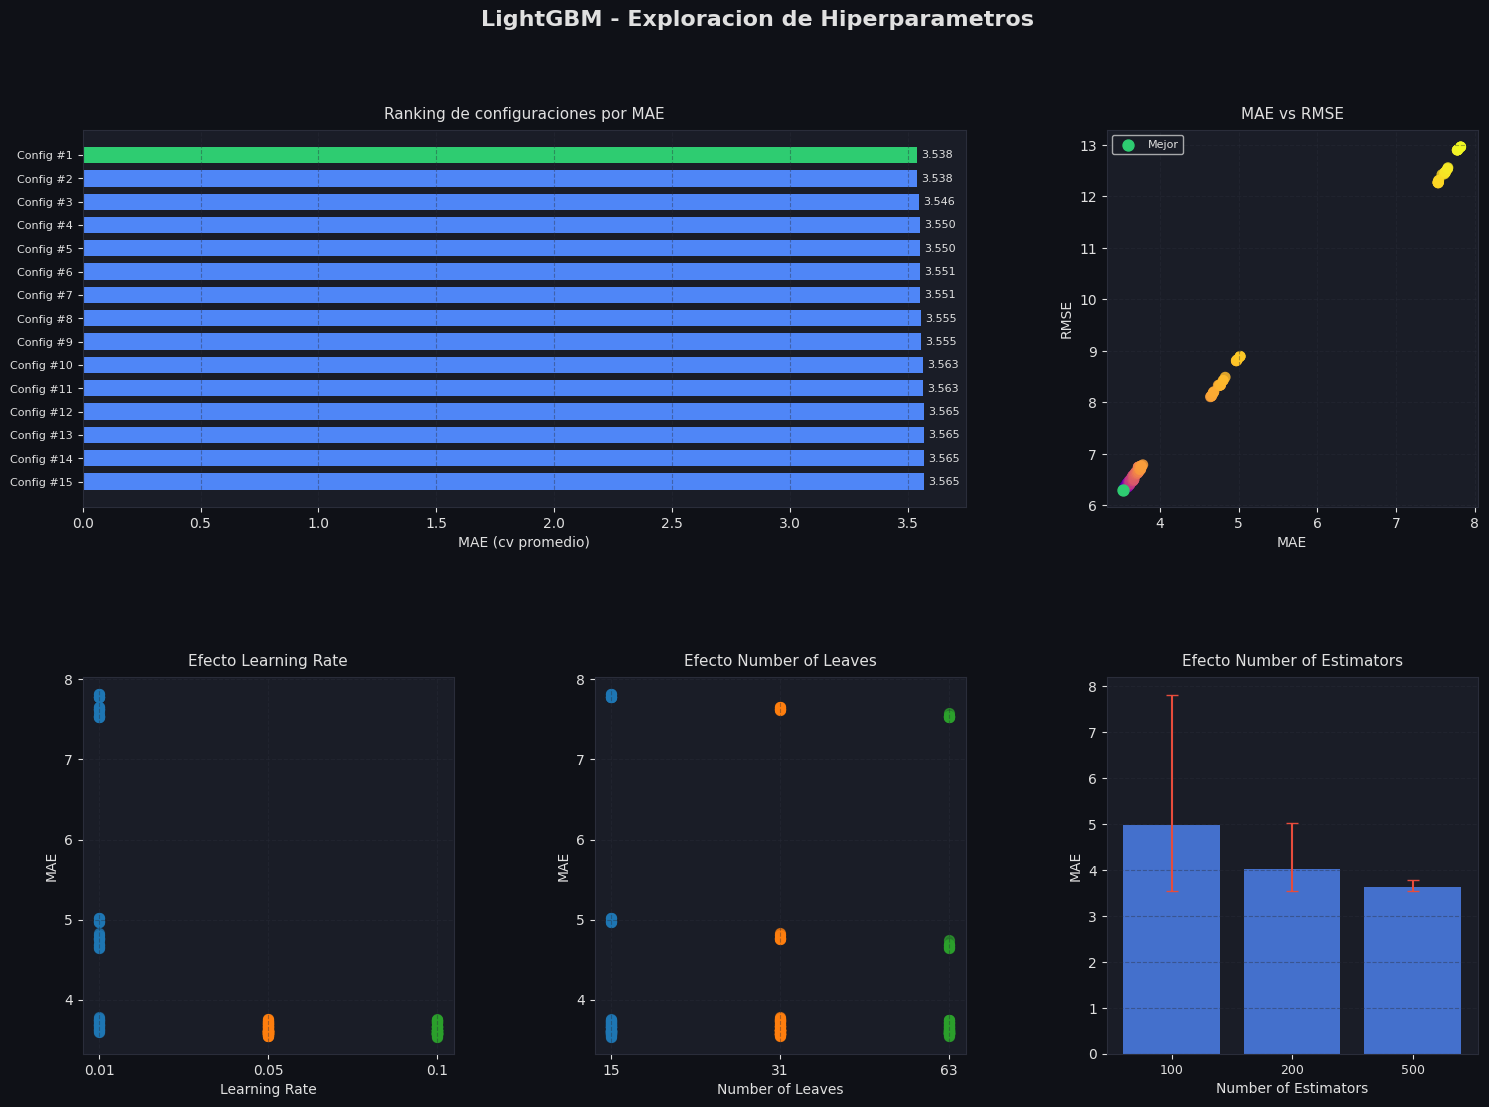

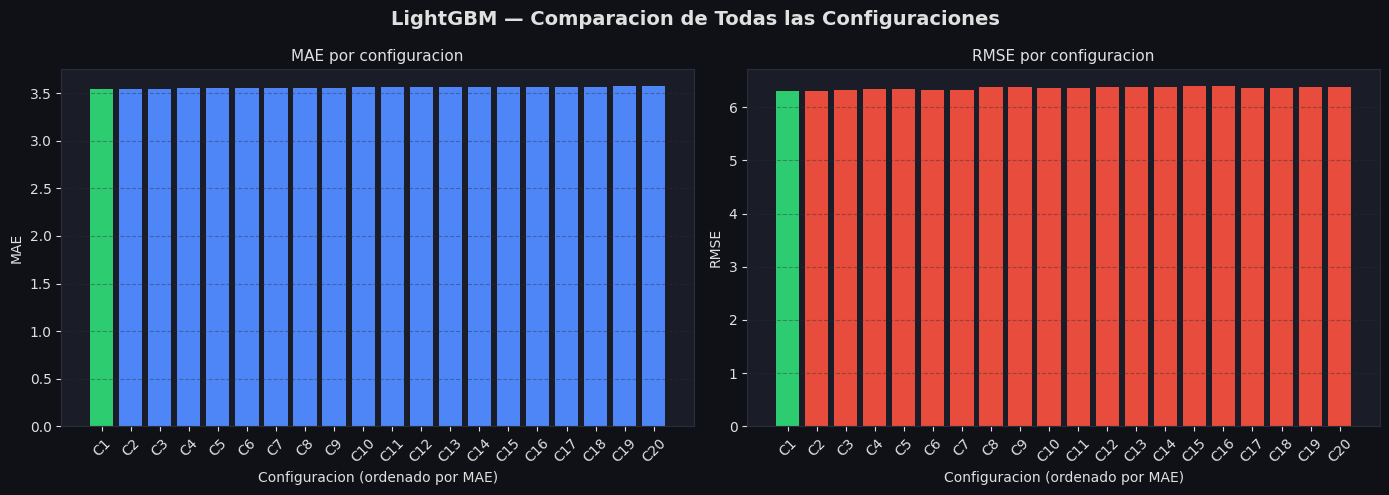

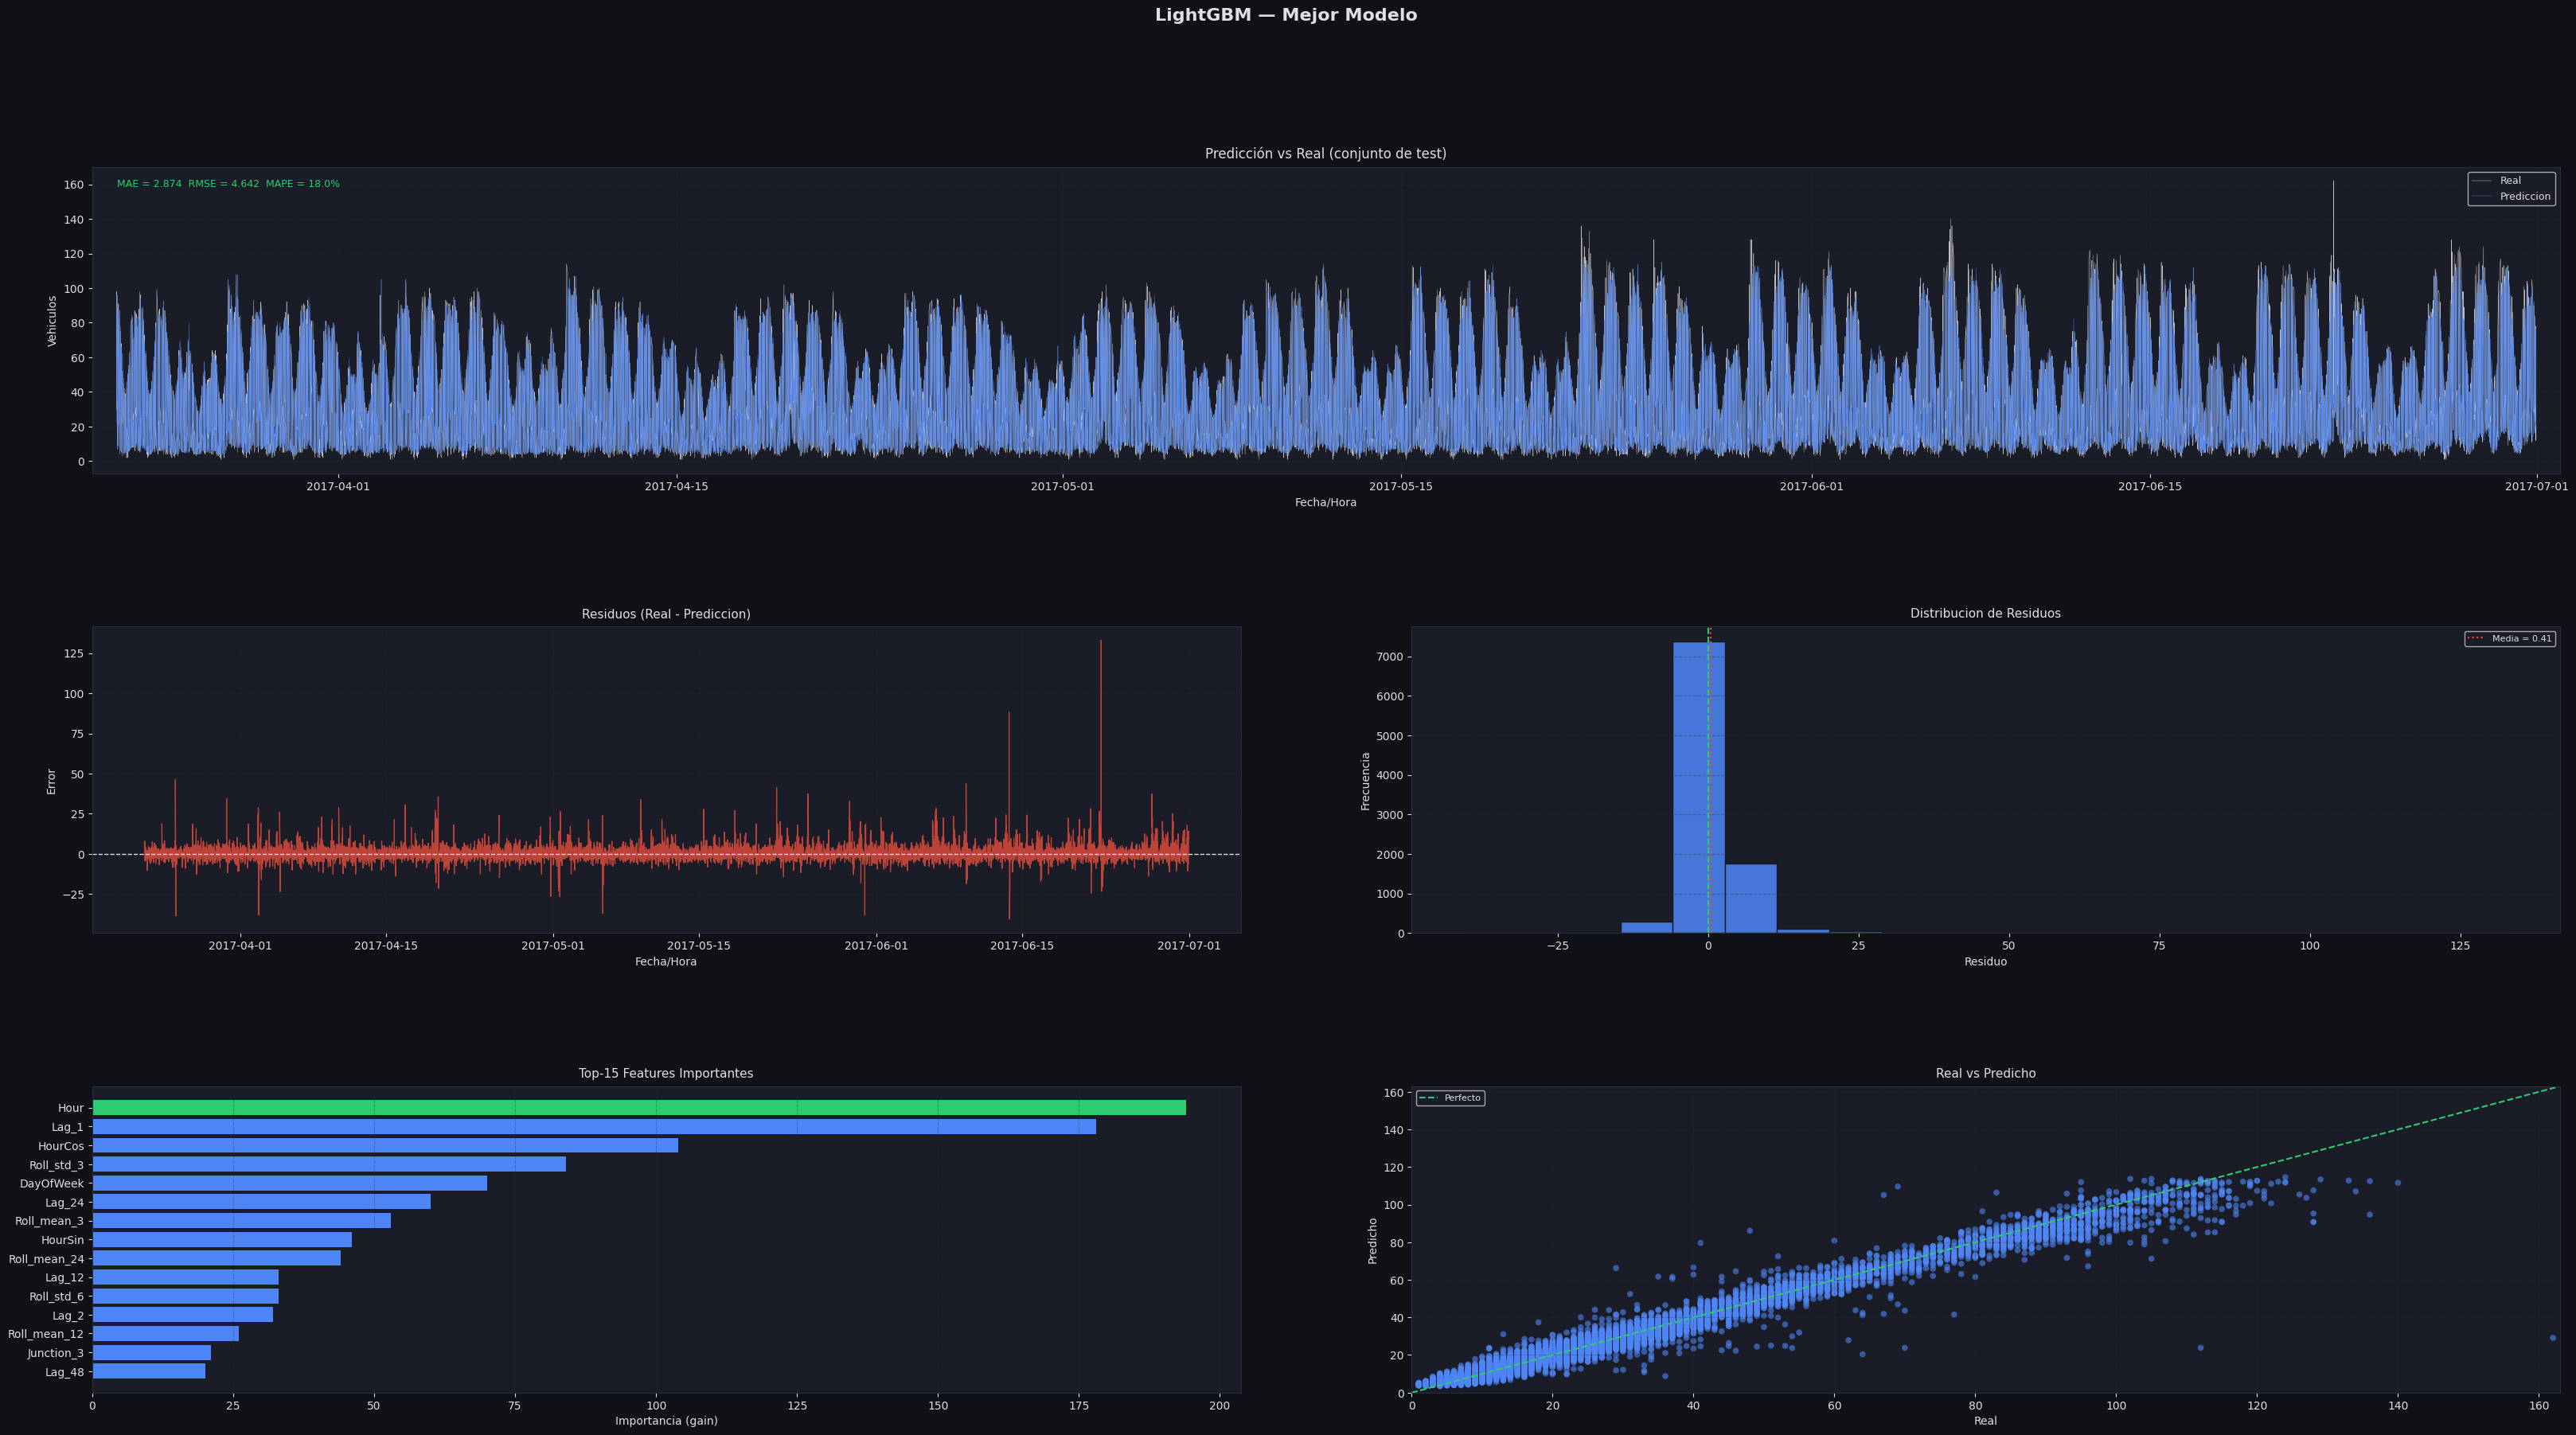

In [242]:
results_df = busqueda_hiperparametros(nuevoDataFrame)

plot_busqueda_hiperparametros(results_df)

plot_comparacion_modelos(results_df)

model, X_tr, X_te, y_tr, y_te, preds, dates = entrenar_mejor_modelo(nuevoDataFrame, results_df)

plot_mejor_modelo(model, y_te, preds, dates, FEATURE_COLS)